In [43]:
import pandas as pd

In [44]:
# Load dataset
df = pd.read_excel("Cinnamon_Exports_from_2004.xlsx")

In [45]:
df

,Year,Month,HsNo,Description,Country,Unit,Quantity,ExP_Value_in_USD
0,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,Australia,Kg,50,354.6652
1,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,Canada,Kg,1199,2710.1921
2,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,France,Kg,5,32.0195
3,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,Germany,Kg,6742,44805.0567
4,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,India,Kg,7000,24219.2682
...,...,...,...,...,...,...,...,...
28459,2025,6,33019040,"Other: ---Other, of Cinnamon bark","Korea South (Korea, Republic of)",Kg,10,2376.8345
28460,2025,6,33019040,"Other: ---Other, of Cinnamon bark",Maldives,Kg,1,75.4348
28461,2025,6,33019040,"Other: ---Other, of Cinnamon bark",Spain,Kg,50,6978.1902
28462,2025,6,33019040,"Other: ---Other, of Cinnamon bark",United Kingdom,Kg,50,12135.9854


In [46]:
# Check for missing values in raw data
print(df[["Quantity", "ExP_Value_in_USD"]].isna().sum())

Quantity            0
ExP_Value_in_USD    0
dtype: int64


In [47]:
# no missing values

In [48]:
# Check for duplicates (repeated rows with same Year, Month, HsNo, Country)
duplicates = df.duplicated(subset=["Year", "Month", "HsNo", "Country"], keep=False)

# Show the duplicates
print(df[duplicates])

Empty DataFrame
Columns: [Year, Month, HsNo, Description, Country, Unit, Quantity, ExP_Value_in_USD]
Index: []


In [49]:
# there are no duplicate rows

In [50]:
# Combining Year and Month into a Period column
df["Period"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
).dt.to_period("M")

In [51]:
df

,Year,Month,HsNo,Description,Country,Unit,Quantity,ExP_Value_in_USD,Period
0,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,Australia,Kg,50,354.6652,2004-01
1,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,Canada,Kg,1199,2710.1921,2004-01
2,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,France,Kg,5,32.0195,2004-01
3,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,Germany,Kg,6742,44805.0567,2004-01
4,2004,1,9061001,Cinnamon quills cut in retail packs of 1kg or ...,India,Kg,7000,24219.2682,2004-01
...,...,...,...,...,...,...,...,...,...
28459,2025,6,33019040,"Other: ---Other, of Cinnamon bark","Korea South (Korea, Republic of)",Kg,10,2376.8345,2025-06
28460,2025,6,33019040,"Other: ---Other, of Cinnamon bark",Maldives,Kg,1,75.4348,2025-06
28461,2025,6,33019040,"Other: ---Other, of Cinnamon bark",Spain,Kg,50,6978.1902,2025-06
28462,2025,6,33019040,"Other: ---Other, of Cinnamon bark",United Kingdom,Kg,50,12135.9854,2025-06


In [52]:
# Group by Period and aggregate
df = df.groupby("Period", as_index=False).agg({
    "Quantity": "sum",
    "ExP_Value_in_USD": "sum"
})

In [53]:
df

,Period,Quantity,ExP_Value_in_USD
0,2004-01,977454,4.008277e+06
1,2004-02,685426,2.798615e+06
2,2004-03,842386,3.255487e+06
3,2004-04,667773,2.771190e+06
4,2004-05,751436,3.107719e+06
...,...,...,...
253,2025-02,1404922,1.848532e+07
254,2025-03,1493578,1.963385e+07
255,2025-04,826830,1.001999e+07
256,2025-05,1293496,1.688522e+07


In [54]:
# the dataset contained multiple entires for each month based on cinnamon product type and export destination country. these were aggregated monthly to
# get total cinnamon exports for each month.

In [55]:
# Rename columns
df.rename(columns={
    "Quantity": "Total Quantity (Kg)",
    "ExP_Value_in_USD": "Total Export Value (USD)"
}, inplace=True)

In [56]:
# Convert Kg to Tonnes
df["Total Quantity (Tonnes)"] = df["Total Quantity (Kg)"] / 1000

In [57]:
df

,Period,Total Quantity (Kg),Total Export Value (USD),Total Quantity (Tonnes)
0,2004-01,977454,4.008277e+06,977.454
1,2004-02,685426,2.798615e+06,685.426
2,2004-03,842386,3.255487e+06,842.386
3,2004-04,667773,2.771190e+06,667.773
4,2004-05,751436,3.107719e+06,751.436
...,...,...,...,...
253,2025-02,1404922,1.848532e+07,1404.922
254,2025-03,1493578,1.963385e+07,1493.578
255,2025-04,826830,1.001999e+07,826.830
256,2025-05,1293496,1.688522e+07,1293.496


In [58]:
# Convert Period to timestamp index
df['Period'] = df['Period'].dt.to_timestamp()
df = df.set_index('Period')

In [59]:
# Create a full monthly date range
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')

In [60]:
# Find missing months
missing_months = full_range.difference(df.index)

print("Missing months:")
print(missing_months)

Missing months:
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [61]:
# no missing months

In [62]:
# number of data points
len(df)

258

In [63]:
# Convert Period to YYYY-MM format as string
df = df.reset_index()  # reset period set as index
df['Period'] = df['Period'].dt.strftime('%Y-%m')

In [64]:
# Save DataFrame to Downloads folder
df.to_excel(r"C:\Users\HP\Downloads\monthly_export_summary.xlsx", index=False)

print("File saved to C:\\Users\\HP\\Downloads\\monthly_export_summary.xlsx")

df.head(15)

File saved to C:\Users\HP\Downloads\monthly_export_summary.xlsx


,Period,Total Quantity (Kg),Total Export Value (USD),Total Quantity (Tonnes)
0,2004-01,977454,4.008277e+06,977.454
1,2004-02,685426,2.798615e+06,685.426
2,2004-03,842386,3.255487e+06,842.386
3,2004-04,667773,2.771190e+06,667.773
4,2004-05,751436,3.107719e+06,751.436
5,2004-06,866854,3.651483e+06,866.854
6,2004-07,1004819,4.259966e+06,1004.819
7,2004-08,1004518,4.445516e+06,1004.518
8,2004-09,1140042,5.068298e+06,1140.042
9,2004-10,1172841,4.888640e+06,1172.841


# ANN and Fuzzy Time Series

In [248]:
# Load dataset
import pandas as pd
df = pd.read_excel("monthly_export_summary.xlsx")

In [249]:
df = df.rename(columns={
    "Total Quantity (Tonnes)": "Total_Quantity_Tonnes"
})
df

,Period,Total Quantity (Kg),Total Export Value (USD),Total_Quantity_Tonnes
0,2004-01,977454,4.008277e+06,977.454
1,2004-02,685426,2.798615e+06,685.426
2,2004-03,842386,3.255487e+06,842.386
3,2004-04,667773,2.771190e+06,667.773
4,2004-05,751436,3.107719e+06,751.436
...,...,...,...,...
253,2025-02,1404922,1.848532e+07,1404.922
254,2025-03,1493578,1.963385e+07,1493.578
255,2025-04,826830,1.001999e+07,826.830
256,2025-05,1293496,1.688522e+07,1293.496


In [250]:
# Convert Period column to datetime
df['Period'] = pd.to_datetime(df['Period'])

# Sort by date
df = df.sort_values('Period').reset_index(drop=True)

# ANN

In [251]:
import numpy as np
import pandas as pd

In [252]:
# Define the target variable
y = df['Total_Quantity_Tonnes'].values

In [253]:
def create_lagged_data(series, lags):
    X, y = [], []
    for i in range(max(lags), len(series)):
        X.append([series[i - lag] for lag in lags])
        y.append(series[i])
    return np.array(X), np.array(y)

In [254]:
# Lagged arrays
lags = [1, 12] 
X, y_target = create_lagged_data(y, lags)

In [255]:
# Train/Validation/Test split (last 12 months test, 12 months validation)
n_val  = 12
n_test = 12

X_test, y_test   = X[-n_test:], y_target[-n_test:]
X_val, y_val     = X[-(n_test+n_val):-n_test], y_target[-(n_test+n_val):-n_test]
X_train, y_train = X[:-(n_test+n_val)], y_target[:-(n_test+n_val)]

# Periods for verification
train_periods = df['Period'].iloc[:-(n_test+n_val)]
val_periods   = df['Period'].iloc[-(n_test+n_val):-n_test]
test_periods  = df['Period'].iloc[-n_test:]

print(
    "Train period:",
    train_periods.min(), "to", train_periods.max(),
    "| Total data points:", len(train_periods)
)

print(
    "Validation period:",
    val_periods.min(), "to", val_periods.max(),
    "| Total data points:", len(val_periods)
)

print(
    "Test period:",
    test_periods.min(), "to", test_periods.max(),
    "| Total data points:", len(test_periods)
)

Train period: 2004-01-01 00:00:00 to 2023-06-01 00:00:00 | Total data points: 234
Validation period: 2023-07-01 00:00:00 to 2024-06-01 00:00:00 | Total data points: 12
Test period: 2024-07-01 00:00:00 to 2025-06-01 00:00:00 | Total data points: 12


In [256]:
# standardization
mean = X_train.mean()
std  = X_train.std()

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

y_mean = y_train.mean()
y_std  = y_train.std()

y_train = (y_train - y_mean) / y_std
y_val   = (y_val - y_mean) / y_std
y_test  = (y_test - y_mean) / y_std

In [257]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)

HIDDEN_NEURONS = 3
LEARNING_RATE = 0.01
EPOCHS = 300
BATCH_SIZE = 7

model = Sequential()

# Input layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layer (sigmoid)
model.add(Dense(
    units=HIDDEN_NEURONS,      
    activation='sigmoid'
))

# Output layer with identity (linear) activation
model.add(Dense(
    units=1,
    activation='linear'
))

model.compile(
    optimizer=Adam(LEARNING_RATE),
    loss='mse'
)

# early stopping
es = EarlyStopping(
    monitor='val_loss',       # monitor validation loss
    patience=10,              # stop after 10 epochs with no improvement
    restore_best_weights=True # restore weights from the best epoch
)

# model checkpoint
checkpoint = ModelCheckpoint(
    "best_ann_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# The ANN was implemented using Keras. Weights were initialized automatically, and the model was trained using backpropagation with the Adam optimizer.
# Hyperparameters such as the number of hidden neurons, learning rate, and batch size tuned using the validation set.

# train 
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, checkpoint],
    verbose=1
)

Epoch 1/300
29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0998
Epoch 1: val_loss improved from inf to 1.13985, saving model to best_ann_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.0850 - val_loss: 1.1399
Epoch 2/300
22/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6910 
Epoch 2: val_loss improved from 1.13985 to 0.79702, saving model to best_ann_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6839 - val_loss: 0.7970
Epoch 3/300
25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4844 
Epoch 3: val_loss improved from 0.79702 to 0.59600, saving model to best_ann_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4846 - val_loss: 0.5960
Epoch 4/300
23/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3813 
Epoch 4: val_loss improved from 0.59600 to 0.50701, saving model to best_ann_model.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3921 - val_loss: 0.5070
Epoch 5/300
28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3524 
Epoch 5: val_loss imp

In [258]:
from tensorflow.keras.models import load_model
# The ANN model corresponding to the minimum validation loss was saved using ModelCheckpoint and reloaded for testing
best_model = load_model("best_ann_model.keras")

In [259]:
# Inverse normalization to get predictions and actual values in original scale
y_pred_norm = best_model.predict(X_test)

y_pred = y_pred_norm * y_std + y_mean
y_actual = y_test * y_std + y_mean

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


In [260]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox


# Calculate RMSE, MAE, MAPE
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae  = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 323.56
MAE : 258.84
MAPE: 28.57%


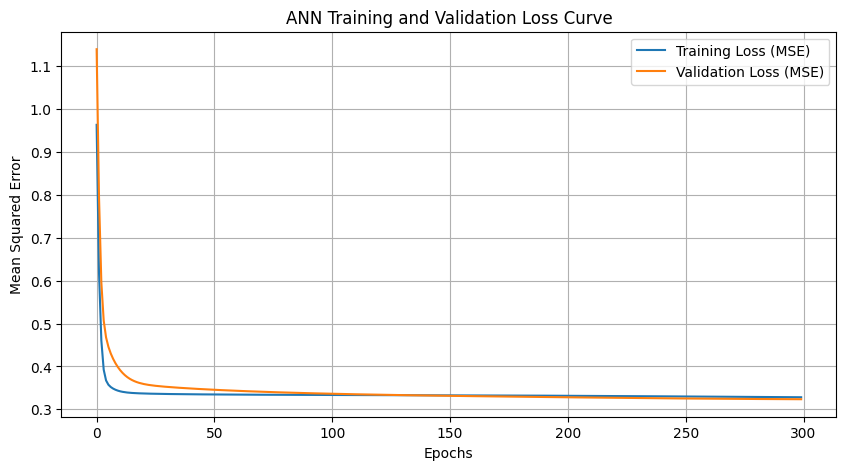

In [261]:
import matplotlib.pyplot as plt

# Extract loss values
train_loss = history.history['loss']
val_loss   = history.history['val_loss']

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss (MSE)')
plt.plot(val_loss, label='Validation Loss (MSE)')

plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('ANN Training and Validation Loss Curve')
plt.legend()
plt.grid(True)

plt.show()

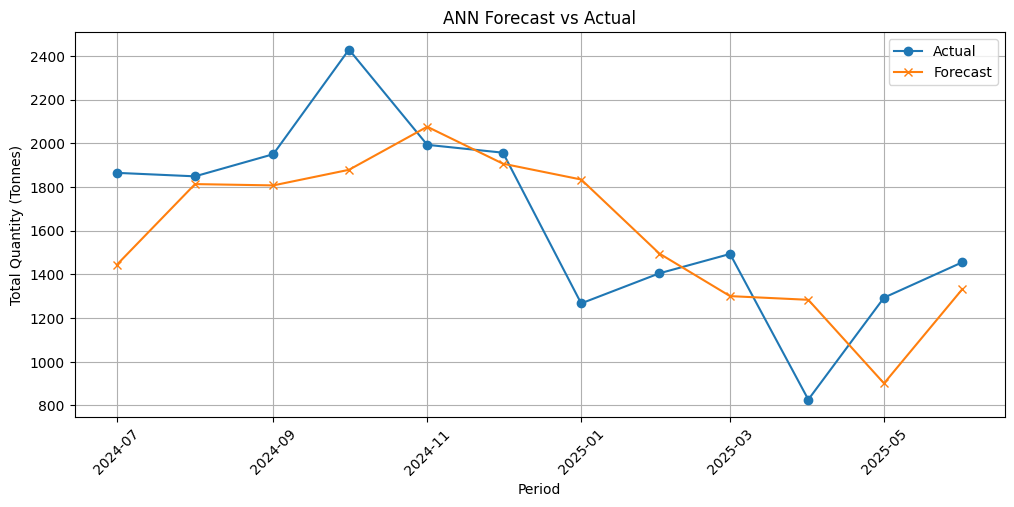

In [262]:
# Plot actual vs forecast
plt.figure(figsize=(12,5))
plt.plot(test_periods.values, y_actual, label='Actual', marker='o')
plt.plot(test_periods.values, y_pred, label='Forecast', marker='x')
plt.xticks(rotation=45)
plt.xlabel('Period')
plt.ylabel('Total Quantity (Tonnes)')
plt.title('ANN Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()

# Fuzzy time series

In [285]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox

In [286]:
y = df['Total_Quantity_Tonnes'].values
periods = df['Period']

In [287]:
n_test = 24

y_test  = y[-n_test:]     
y_train = y[:-n_test]       

In [288]:
# universe of discourse 
def define_universe(data, D1=10, D2=10):
    return data.min() - D1, data.max() + D2

U_min, U_max = define_universe(y_train)

print("Universe of Discourse:")
print(f"U = [{U_min}, {U_max}]")

Universe of Discourse:
U = [336.781, 2673.187]


In [289]:
num_intervals = 5

n = len(y_train)
print("Number of train data points:", n)
print("Number of intervals:", num_intervals)

Number of train data points: 234
Number of intervals: 5


In [290]:
# partition universe into equal intervals

def create_intervals(U_min, U_max, n_intervals=num_intervals):
    bounds = np.linspace(U_min, U_max, n_intervals + 1) # n + 1 points for n intervals
    intervals = [(bounds[i], bounds[i+1]) for i in range(n_intervals)]
    midpoints = [(low + high) / 2 for low, high in intervals]
    return intervals, midpoints

intervals, midpoints = create_intervals(U_min, U_max)

print("\nPartition of Universe of Discourse:")
for i, (low, high) in enumerate(intervals, start=1):
    print(f"u{i} = [{low:.2f}, {high:.2f}]")


Partition of Universe of Discourse:
u1 = [336.78, 804.06]
u2 = [804.06, 1271.34]
u3 = [1271.34, 1738.62]
u4 = [1738.62, 2205.91]
u5 = [2205.91, 2673.19]


In [291]:
# Linguistic values
fuzzy_labels = {
    0: "Very Low Exports",
    1: "Low Exports",
    2: "Average Exports",
    3: "High Exports",
    4: "Very High Exports"
}

In [292]:
# discrete fuzzification
def fuzzify(value, intervals):
    memberships = []

    for i, (low, high) in enumerate(intervals):

        if low <= value <= high:
            mu = 1.0
        elif i > 0 and intervals[i-1][0] <= value <= intervals[i-1][1]:
            mu = 0.5
        elif i < len(intervals) - 1 and intervals[i+1][0] <= value <= intervals[i+1][1]:
            mu = 0.5
        else:
            mu = 0.0

        memberships.append(mu)

    return np.argmax(memberships) # returns the index of the highest membership value

In [293]:
# fuzzify training data
# Each training observation is fuzzified using membership functions and assigned to a fuzzy set based on the maximum membership principle

fuzzy_train = [fuzzify(v, intervals) for v in y_train]

In [294]:
# Year–Value–Fuzzy Set
table = pd.DataFrame({
    "Period": periods[:len(y_train)],
    "Actual_Value": y_train,
    "Fuzzy_Set": [f"A{i+1}" for i in fuzzy_train],
    "Linguistic_Value": [fuzzy_labels[i] for i in fuzzy_train]
})

print("\nYear–Value–Fuzzy Set:")
print(table.head(20))


Year–Value–Fuzzy Set:
       Period  Actual_Value Fuzzy_Set  Linguistic_Value
0  2004-01-01       977.454        A2       Low Exports
1  2004-02-01       685.426        A1  Very Low Exports
2  2004-03-01       842.386        A2       Low Exports
3  2004-04-01       667.773        A1  Very Low Exports
4  2004-05-01       751.436        A1  Very Low Exports
5  2004-06-01       866.854        A2       Low Exports
6  2004-07-01      1004.819        A2       Low Exports
7  2004-08-01      1004.518        A2       Low Exports
8  2004-09-01      1140.042        A2       Low Exports
9  2004-10-01      1172.841        A2       Low Exports
10 2004-11-01      1240.145        A2       Low Exports
11 2004-12-01      1188.729        A2       Low Exports
12 2005-01-01      1077.844        A2       Low Exports
13 2005-02-01       960.979        A2       Low Exports
14 2005-03-01       605.141        A1  Very Low Exports
15 2005-04-01       346.781        A1  Very Low Exports
16 2005-05-01       637.8

In [295]:
num_sets = len(intervals)

print("Number of data points per fuzzy set (maximum membership):")
for i in range(num_sets):
    count = fuzzy_train.count(i)
    label = fuzzy_labels[i]
    print(f"Fuzzy Set A{i+1} ({label}): {count} data points")

Number of data points per fuzzy set (maximum membership):
Fuzzy Set A1 (Very Low Exports): 38 data points
Fuzzy Set A2 (Low Exports): 89 data points
Fuzzy Set A3 (Average Exports): 78 data points
Fuzzy Set A4 (High Exports): 22 data points
Fuzzy Set A5 (Very High Exports): 7 data points


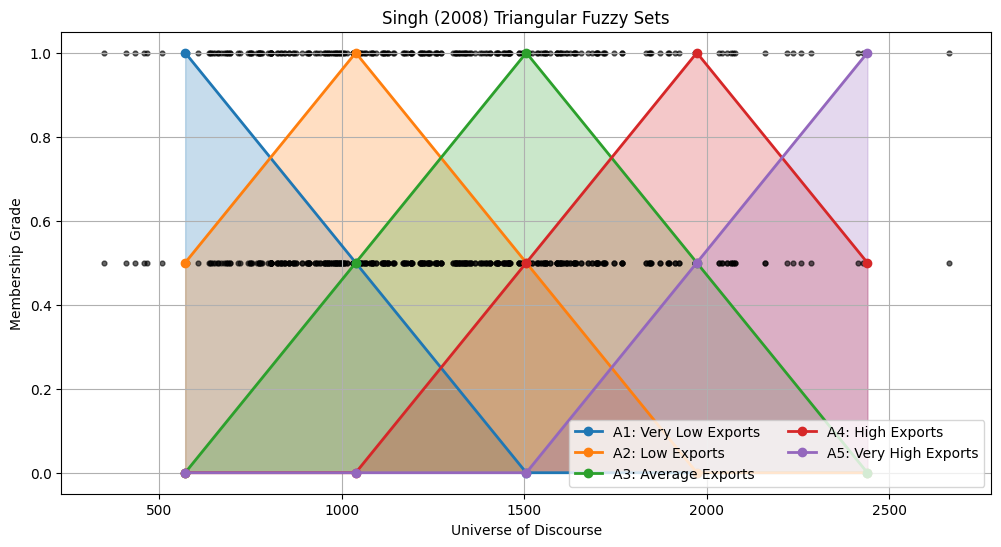

In [296]:
import matplotlib.pyplot as plt

# Interval midpoints
centers = [(low + high) / 2 for low, high in intervals]

plt.figure(figsize=(12,6))

colors = plt.cm.tab10.colors

for i in range(len(intervals)):
    mu = [0.0] * len(intervals)

    if i > 0:
        mu[i-1] = 0.5
    mu[i] = 1.0
    if i < len(intervals)-1:
        mu[i+1] = 0.5

    # Outline
    plt.plot(
        centers, mu,
        marker='o',
        color=colors[i % len(colors)],
        linewidth=2,
        label=f"A{i+1}: {fuzzy_labels[i]}"
    )

    # Fill triangle
    plt.fill_between(
        centers, mu, 0,
        color=colors[i % len(colors)],
        alpha=0.25
    )

# Plot historical points with membership
for y_value in y_train:
    mus = [0.0] * len(intervals)
    for i, (low, high) in enumerate(intervals):
        if low <= y_value <= high:
            mus[i] = 1.0
            if i > 0:
                mus[i-1] = 0.5
            if i < len(intervals)-1:
                mus[i+1] = 0.5
            break

    for mu in mus:
        if mu > 0:
            plt.scatter(y_value, mu, color='black', s=12, alpha=0.6)

plt.xlabel("Universe of Discourse")
plt.ylabel("Membership Grade")
plt.title("Singh (2008) Triangular Fuzzy Sets")
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [297]:
# fuzzy logical relationships
def build_flr(fuzzy_series):
    flr = {}
    for i in range(len(fuzzy_series) - 1):
        curr_state = fuzzy_series[i]
        next_state = fuzzy_series[i + 1]
        if curr_state not in flr:
            flr[curr_state] = []
        flr[curr_state].append(next_state)
    return flr

flr = build_flr(fuzzy_train)

In [299]:
# converts a fuzzy set into a value by taking the midpoint of the corresponding interval.
def defuzzify_midpoint(fuzzy_index, intervals):
    low, high = intervals[fuzzy_index]
    return (low + high) / 2

In [300]:
defuzz_func = defuzzify_midpoint

In [301]:
# order 3 forecast function
# Capture the trend/direction from past 3 actual values
def singh_forecast(y_train, fuzzy_train, flr, defuzz_func):
    forecasts = [None, None, None] # order three forecast - it needs 3 past actual values to compute the trend. forecast starts at i = 2

    for i in range(2, len(y_train) - 1): # Loops from the 3rd element (i=2) to the second last element
                                         # At each step the function forecasts the next value (y_train[i+1]) based on fuzzy logic and trend

        # Time-variant parameter Dn
        Dn = abs(y_train[i] - y_train[i-1]) - abs(y_train[i-1] - y_train[i-2])

        curr_fuzzy = fuzzy_train[i]

        if curr_fuzzy in flr:
            next_states = flr[curr_fuzzy]
            Aj = max(set(next_states), key=next_states.count)
            forecast = defuzz_func(Aj, intervals) + Dn
        else:
            forecast = y_train[i]  # fallback

        forecasts.append(forecast) # Adds the computed forecast to the list of forecasts

    forecasts.append(None) # last point cannot forecast beyond the series
    return forecasts

y_train - The actual historical values of the time series.

fuzzy_train - A list of fuzzy states corresponding to y_train ("Very Low Exports", "Low Exports", "Average Exports", "High Exports", "Very High Exports").

flr - Fuzzy logical relationships – a dictionary mapping each fuzzy state to its possible next states. 

for example - 

flr = {

    'Very Low Exports': ['Very Low Exports', 'Low Exports', 'Average Exports', 'High Exports', 'Very High Exports'],
    
    'Low Exports': ['Very Low Exports', 'Low Exports', 'Average Exports', 'High Exports', 'Very High Exports'],
    
    'Average Exports': ['Very Low Exports', 'Low Exports', 'Average Exports', 'High Exports', 'Very High Exports'],
    
    'High Exports': ['Very Low Exports', 'Low Exports', 'Average Exports', 'High Exports', 'Very High Exports'],
    
    'Very High Exports': ['Very Low Exports', 'Low Exports', 'Average Exports', 'High Exports', 'Very High Exports']
}


In [302]:
# forecast test set 
combined_y = np.concatenate([y_train[-3:], y_test])
combined_fuzzy = [fuzzify(v, intervals) for v in combined_y]

combined_forecast = singh_forecast(
    combined_y,
    combined_fuzzy,
    flr, 
    defuzz_func
)

test_forecast = combined_forecast[3:3 + len(y_test)]

In [303]:
# evaluation
results = pd.DataFrame({
    'Actual': y_test,
    'Forecast': test_forecast
}).dropna()

results['Error'] = results['Forecast'] - results['Actual']

rmse = np.sqrt(mean_squared_error(results['Actual'], results['Forecast']))
mae  = mean_absolute_error(results['Actual'], results['Forecast'])
mape = np.mean(np.abs(results['Error'] / results['Actual'])) * 100

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")

RMSE : 354.60
MAE  : 296.61
MAPE : 19.80%


In [304]:
# Ljung box test
lb_test = acorr_ljungbox(results['Error'], lags=[5], return_df=True)
print(lb_test)

    lb_stat  lb_pvalue
5  1.741993   0.883567


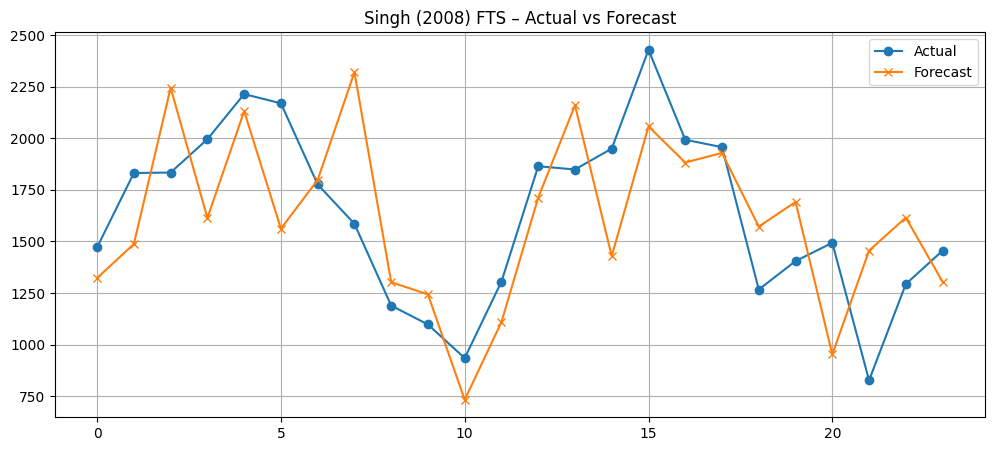

In [305]:
# Actual vs forecast plot
plt.figure(figsize=(12,5))
plt.plot(results['Actual'], marker='o', label='Actual')
plt.plot(results['Forecast'], marker='x', label='Forecast')
plt.title('Singh (2008) FTS – Actual vs Forecast')
plt.legend()
plt.grid(True)
plt.show()